# Optimization techniques : Graph-based optimization for resource allocation during an outbreak

**Case Study:** Epidemic Resource Allocation Network in Wrocław, Poland.

In the context of resource allocation during an outbreak (e.g., vaccine distribution, routing ICU beds from logistics centers $s$ to hospitals $t$), modeling the distribution network as a graph enables critical decision-making. 

This notebook explores three advanced graph-optimization studies:
1. Edge Sensitivity Analysis (Max-Flow Min-Cut)
2. Identifying the Most Vital Edge (Vulnerability Analysis)
3. Network Design under Budget Constraints (Greedy Heuristics vs. Linear Programming)

## Summary

**TO DO**

## Importation

In [3]:
# main importation

import networkx as nx
import matplotlib.pyplot as plt
import pulp
import numpy as np
import random
import time

## Graph construction

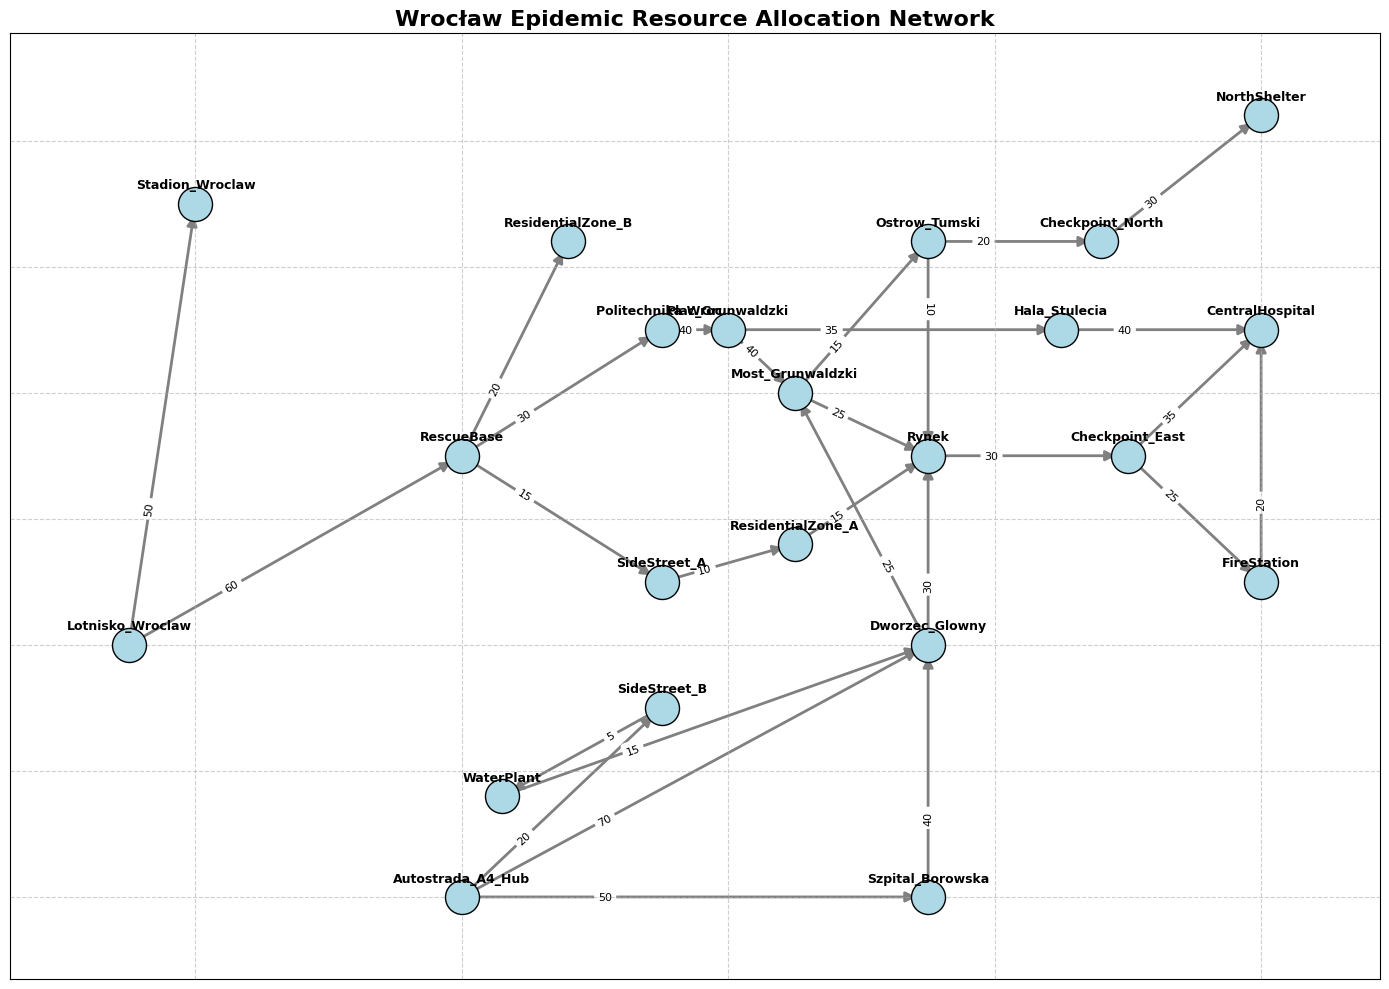

In [4]:
# WROCŁAW GRAPH DEFINITION
NODE_POSITIONS = {
    'RescueBase'         : (0.0,  2.5),
    'Politechnika Wroc.' : (1.5,  3.5),
    'Most_Grunwaldzki'   : (2.5,  3.0),
    'Ostrow_Tumski'      : (3.5,  4.2),
    'Rynek'              : (3.5,  2.5),
    'Dworzec_Glowny'     : (3.5,  1.0),
    'SideStreet_A'       : (1.5,  1.5),
    'SideStreet_B'       : (1.5,  0.5),
    'ResidentialZone_A'  : (2.5,  1.8),
    'ResidentialZone_B'  : (0.8,  4.2),
    'WaterPlant'         : (0.3, -0.2),
    'Checkpoint_North'   : (4.8,  4.2),
    'Checkpoint_East'    : (5.0,  2.5),
    'CentralHospital'    : (6.0,  3.5),
    'NorthShelter'       : (6.0,  5.2),
    'FireStation'        : (6.0,  1.5),
    'Lotnisko_Wroclaw'   : (-2.5,  1.0), 
    'Stadion_Wroclaw'    : (-2.0,  4.5), 
    'Plac_Grunwaldzki'   : (2.0,  3.5),  
    'Szpital_Borowska'   : (3.5, -1.0),  
    'Hala_Stulecia'      : (4.5,  3.5),  
    'Autostrada_A4_Hub'  : (0.0, -1.0)   
}

edges_data = [
    ('Lotnisko_Wroclaw', 'RescueBase', 60),
    ('Lotnisko_Wroclaw', 'Stadion_Wroclaw', 50),
    ('Autostrada_A4_Hub', 'Dworzec_Glowny', 70),
    ('Autostrada_A4_Hub', 'Szpital_Borowska', 50),
    ('Autostrada_A4_Hub', 'SideStreet_B', 20), 
    ('SideStreet_B', 'WaterPlant', 5),         
    ('WaterPlant', 'Dworzec_Glowny', 15),      
    ('RescueBase', 'Politechnika Wroc.', 30),
    ('RescueBase', 'SideStreet_A', 15),
    ('RescueBase', 'ResidentialZone_B', 20),
    ('Politechnika Wroc.', 'Plac_Grunwaldzki', 40),
    ('Plac_Grunwaldzki', 'Most_Grunwaldzki', 40),
    ('Plac_Grunwaldzki', 'Hala_Stulecia', 35),
    ('Most_Grunwaldzki', 'Rynek', 25),
    ('Most_Grunwaldzki', 'Ostrow_Tumski', 15), 
    ('Ostrow_Tumski', 'Rynek', 10),
    ('Dworzec_Glowny', 'Rynek', 30),
    ('Dworzec_Glowny', 'Most_Grunwaldzki', 25),
    ('Szpital_Borowska', 'Dworzec_Glowny', 40),
    ('SideStreet_A', 'ResidentialZone_A', 10),
    ('ResidentialZone_A', 'Rynek', 15),
    ('Rynek', 'Checkpoint_East', 30),
    ('Ostrow_Tumski', 'Checkpoint_North', 20),
    ('Hala_Stulecia', 'CentralHospital', 40),
    ('Checkpoint_East', 'CentralHospital', 35),
    ('Checkpoint_East', 'FireStation', 25),
    ('Checkpoint_North', 'NorthShelter', 30),
    ('FireStation', 'CentralHospital', 20)
]

def build_and_draw_wroclaw_graph():
    G = nx.DiGraph()
    for node, pos in NODE_POSITIONS.items():
        G.add_node(node, pos=pos)
    for u, v, cap in edges_data:
        G.add_edge(u, v, capacity=cap)
        
    plt.figure(figsize=(14, 10))
    plt.title("Wrocław Epidemic Resource Allocation Network", fontsize=16, fontweight='bold')
    pos = nx.get_node_attributes(G, 'pos')
    
    # Draw graph elements
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, edge_color='gray', width=2)
    label_pos = {k: (v[0], v[1]+0.15) for k, v in pos.items()}
    nx.draw_networkx_labels(G, label_pos, font_size=9, font_weight='bold')
    edge_labels = nx.get_edge_attributes(G, 'capacity')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('on') 
    plt.tight_layout()
    plt.show()
    return G

wroclaw_graph = build_and_draw_wroclaw_graph()
SOURCE = 'Lotnisko_Wroclaw'
SINK = 'CentralHospital'

## Part 1: Sensitivity to Capacity Augmentation

**Mathematical Context:**
The Max-Flow problem seeks to send the maximum amount of resources from a source $s$ to a sink $t$ in a directed graph $G=(V, E)$, where each edge $(i,j)$ has a maximum capacity $c_{ij}$. 

Mathematically, we maximize the total flow $v$ subject to two constraints:
1. **Flow Conservation (Kirchhoff's Law):** For any node $k \in V \setminus \{s,t\}$, the sum of incoming flows equals the sum of outgoing flows.
2. **Capacity Constraint:** $0 \leq f_{ij} \leq c_{ij} \quad \forall (i,j) \in E$.

**Explaining Sensitivity (Max-Flow Min-Cut Theorem):**
The fundamental theorem states that the maximum flow is exactly equal to the capacity of the minimum cut (min-cut). A cut $(S,T)$ is a partition of the nodes such that $s \in S$ and $t \in T$. 
If you increase the capacity $c_{ij}$ of an edge by a value $\delta$, **the total flow $v$ will only increase if the edge $(i,j)$ belongs to the limiting minimum cut.** Increasing $c_{ij}$ anywhere else is a waste of epidemiological resources.

### Implementation

In [5]:
def naive_sensitivity(G, s, t, delta=1):
    """
    Naive approach: Test every single edge to see if increasing its capacity improves the maximum flow.
    """
    base_flow_value = nx.maximum_flow_value(G, s, t)
    sensitivity_results = {}

    for u, v, data in G.edges(data=True):
        original_capacity = data['capacity']
        G[u][v]['capacity'] = original_capacity + delta
        
        new_flow_value = nx.maximum_flow_value(G, s, t)
        sensitivity_results[(u, v)] = new_flow_value - base_flow_value
        
        G[u][v]['capacity'] = original_capacity
        
    return sensitivity_results

def optimized_sensitivity(G, s, t, delta=1):
    """
    Optimized approach: Only test edges that cross the minimum s-t cut.
    """
    base_flow_value = nx.maximum_flow_value(G, s, t)
    sensitivity_results = { (u, v): 0 for u, v in G.edges() }
        
    # Find the minimum cut partition
    cut_value, partition = nx.minimum_cut(G, s, t)
    reachable, non_reachable = partition
    
    cut_edges = [(u, v) for u, v in G.edges() if u in reachable and v in non_reachable]
            
    for u, v in cut_edges:
        original_capacity = G[u][v]['capacity']
        G[u][v]['capacity'] = original_capacity + delta
        
        new_flow_value = nx.maximum_flow_value(G, s, t)
        sensitivity_results[(u, v)] = new_flow_value - base_flow_value
        
        G[u][v]['capacity'] = original_capacity
        
    return sensitivity_results

### Unit tests

In [6]:
# to do

### Tests on the Wroclaw Graph

In [7]:
print(f"--- Baseline Flow ({SOURCE} -> {SINK}) ---")
print(f"Max Flow Value: {nx.maximum_flow_value(wroclaw_graph, SOURCE, SINK)}")

delta_increase = 10.0

# naive method
naive_res = naive_sensitivity(wroclaw_graph, SOURCE, SINK, delta=delta_increase)

print(f"\n--- Naive: Edges with Positive Sensitivity (Gain > 0) for +{delta_increase} capacity ---")
for edge, gain in naive_res.items():
    if gain > 0:
        print(f"Edge {edge}: Flow Gain = +{gain}")

# optimized method

opt_res = optimized_sensitivity(wroclaw_graph, SOURCE, SINK, delta=delta_increase)

print(f"\n--- Optimized: Edges with Positive Sensitivity (Gain > 0) for +{delta_increase} capacity ---")
for edge, gain in opt_res.items():
    if gain > 0:
        print(f"Edge {edge}: Flow Gain = +{gain}")

--- Baseline Flow (Lotnisko_Wroclaw -> CentralHospital) ---
Max Flow Value: 40

--- Naive: Edges with Positive Sensitivity (Gain > 0) for +10.0 capacity ---
Edge ('RescueBase', 'Politechnika Wroc.'): Flow Gain = +10.0
Edge ('SideStreet_A', 'ResidentialZone_A'): Flow Gain = +5

--- Optimized: Edges with Positive Sensitivity (Gain > 0) for +10.0 capacity ---
Edge ('RescueBase', 'Politechnika Wroc.'): Flow Gain = +10.0
Edge ('SideStreet_A', 'ResidentialZone_A'): Flow Gain = +5


### Benchmark

Benchmark starting...
Size N= 10 done. Naive: 0.0028s | Optimized: 0.0005s
Size N= 20 done. Naive: 0.0203s | Optimized: 0.0013s
Size N= 30 done. Naive: 0.0861s | Optimized: 0.0030s
Size N= 40 done. Naive: 0.3426s | Optimized: 0.0109s
Size N= 50 done. Naive: 0.6132s | Optimized: 0.0130s
Size N= 75 done. Naive: 3.0388s | Optimized: 0.0420s
Size N=100 done. Naive: 8.8899s | Optimized: 0.0686s


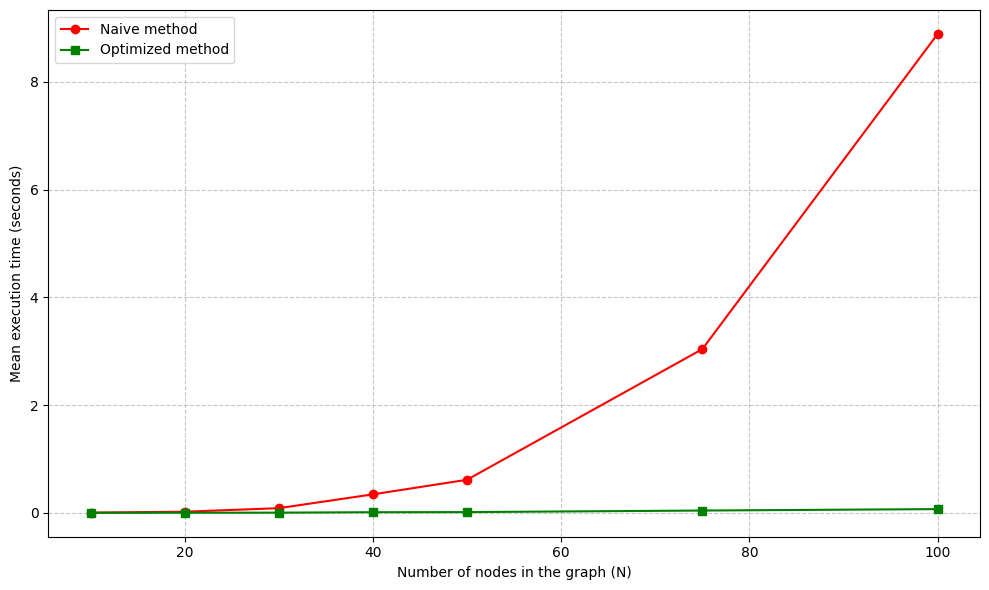

In [8]:
def generate_random_flow_network(n, p=0.3):
    """
    Generate a random oriented graph with caâcity.
    s is the 0 node, t is the n-1 node.
    """
    # using Erdős-Rényi oriented graph
    G = nx.erdos_renyi_graph(n, p, directed=True)
    
    # adding random capcity between 1 and 15
    for (u, v) in G.edges():
        G[u][v]['capacity'] = random.randint(1, 15)
        
    s, t = 0, n - 1
    
    # check if there is a path from s to t
    # otherwise, the flow is 0 and the test is not relevant
    if not nx.has_path(G, s, t):
        # simple path
        for i in range(n-1):
            G.add_edge(i, i+1, capacity=random.randint(5, 15))
            
    return G, s, t

# parameters
node_sizes = [10, 20, 30, 40, 50, 75, 100]
num_trials = 3

times_naive = []
times_optimized = []

print("Benchmark starting...")
    
for n in node_sizes:
    t_naive_total = 0
    t_opt_total = 0
        
    for _ in range(num_trials):
        G, s, t = generate_random_flow_network(n, p=0.2)
            
        # naive method
        start = time.perf_counter()
        naive_sensitivity(G, s, t)
        t_naive_total += (time.perf_counter() - start)
            
        # optimized method
        start = time.perf_counter()
        optimized_sensitivity(G, s, t)
        t_opt_total += (time.perf_counter() - start)
            
    times_naive.append(t_naive_total / num_trials)
    times_optimized.append(t_opt_total / num_trials)
    print(f"Size N={n:3d} done. Naive: {times_naive[-1]:.4f}s | Optimized: {times_optimized[-1]:.4f}s")

# plotting
plt.figure(figsize=(10, 6))
plt.plot(node_sizes, times_naive, label='Naive method', marker='o', color='red')
plt.plot(node_sizes, times_optimized, label='Optimized method', marker='s', color='green')
    
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Mean execution time (seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
    
plt.tight_layout()
plt.show()

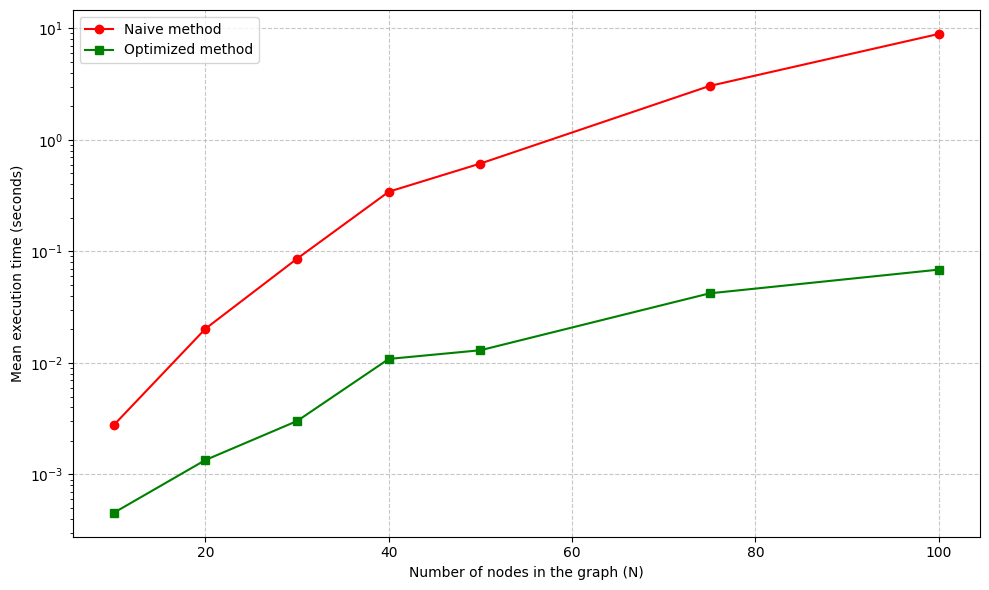

In [9]:
# plotting
plt.figure(figsize=(10, 6))
plt.plot(node_sizes, times_naive, label='Naive method', marker='o', color='red')
plt.plot(node_sizes, times_optimized, label='Optimized method', marker='s', color='green')
    
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Mean execution time (seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#log scale
plt.yscale('log') 

plt.tight_layout()
plt.show()

## Part 2: The Most Vital Edge (Measuring Vulnerability)

**Mathematical Context:**
Here, we are no longer looking at expansion, but at the **resilience** of the network (e.g., what happens if a route is cut off by floods or if a warehouse fails?). 

We define the "vitality" of an edge $e$ by the decrease in the maximum flow value $\Delta v(e)$ when this edge is removed from the network:
$$ \Delta v(e) = |f|_{max}(G) - |f|_{max}(G \setminus \{e\}) $$

**Properties:**
1. **Upper Bound:** $\Delta v(e) \leq f(e) \leq c(e)$.
2. **Relation to the Minimum Cut:** An edge $e$ has a vitality $\Delta v(e) > 0$ **if and only if** it belongs to *all* possible minimum cuts of the graph. If it only belongs to some, the flow can find alternative paths.

In [10]:
def find_most_vital_edge_naive(G, s, t):
    """
    Identifies the 'most vital edge' in a flow network.
    The most vital edge is the one whose removal causes the largest decrease in the maximum flow.
    """
    base_flow_value = nx.maximum_flow_value(G, s, t)
    
    most_vital_edge = None
    max_flow_loss = -1
    edge_losses = {}
    
    for u, v, data in G.edges(data=True):
        original_capacity = data['capacity']
        if original_capacity == 0: continue
            
        # Simulate edge removal
        G[u][v]['capacity'] = 0
        new_flow_value = nx.maximum_flow_value(G, s, t)
        
        flow_loss = base_flow_value - new_flow_value
        edge_losses[(u, v)] = flow_loss
        
        if flow_loss > max_flow_loss:
            max_flow_loss = flow_loss
            most_vital_edge = (u, v)
            
        G[u][v]['capacity'] = original_capacity
        
    return most_vital_edge, max_flow_loss, edge_losses

In [11]:
def find_most_vital_edge_optimized(G, s, t):
    # compute the flow and recuperation of the flow distribution
    base_flow_value, flow_dict = nx.maximum_flow(G, s, t)
    
    most_vital_edge = None
    max_flow_loss = -1
    edge_losses = {} # dict to save all the losses
    
    for u, v, data in G.edges(data=True):
        original_capacity = data['capacity']
        
        # ignore the edges that haven't any capacity
        if original_capacity == 0: 
            edge_losses[(u, v)] = 0
            continue
            
        # optimization here
        # if the edge hasn't flow, his loss is 0
        # we save it to the dict and we do not compute again the total flow
        if flow_dict[u].get(v, 0) == 0:
            edge_losses[(u, v)] = 0
            continue
            
        # simulation of the releting only for active edges
        G[u][v]['capacity'] = 0
        new_flow_value = nx.maximum_flow_value(G, s, t)
        
        flow_loss = base_flow_value - new_flow_value
        edge_losses[(u, v)] = flow_loss
        
        if flow_loss > max_flow_loss:
            max_flow_loss = flow_loss
            most_vital_edge = (u, v)
            
        # restoration of the original capacity
        G[u][v]['capacity'] = original_capacity
        
    return most_vital_edge, max_flow_loss, edge_losses

In [12]:
vital_edge, max_loss, all_losses = find_most_vital_edge_naive(wroclaw_graph, SOURCE, SINK)

print(f"=> The MOST VITAL EDGE is {vital_edge} with a flow loss of {max_loss} units/hr.")
print("\nTop 5 Most Vulnerable Edges:")
sorted_losses = sorted(all_losses.items(), key=lambda item: item[1], reverse=True)
for edge, loss in sorted_losses[:5]:
    if loss > 0:
        print(f"Removing Edge {edge}: Flow Loss = {loss}")

=> The MOST VITAL EDGE is ('Lotnisko_Wroclaw', 'RescueBase') with a flow loss of 40 units/hr.

Top 5 Most Vulnerable Edges:
Removing Edge ('Lotnisko_Wroclaw', 'RescueBase'): Flow Loss = 40
Removing Edge ('RescueBase', 'Politechnika Wroc.'): Flow Loss = 30
Removing Edge ('Politechnika Wroc.', 'Plac_Grunwaldzki'): Flow Loss = 30
Removing Edge ('RescueBase', 'SideStreet_A'): Flow Loss = 10
Removing Edge ('Rynek', 'Checkpoint_East'): Flow Loss = 10


### Benchmark

In [13]:
print("--- Benchmark: Most Vital Edge ---")

# naive test
start_time_naive = time.perf_counter()
vital_edge_n, max_loss_n, all_losses_n = find_most_vital_edge_naive(wroclaw_graph, SOURCE, SINK)
end_time_naive = time.perf_counter()
time_naive = end_time_naive - start_time_naive

# optimized method
start_time_opt = time.perf_counter()
vital_edge_o, max_loss_o, all_losses_o = find_most_vital_edge_optimized(wroclaw_graph, SOURCE, SINK)
end_time_opt = time.perf_counter()
time_opt = end_time_opt - start_time_opt

print(f"Naive method     : Found {vital_edge_n} (Loss: {max_loss_n}) in {time_naive:.5f} seconds")
print(f"Optimized method : Found {vital_edge_o} (Loss: {max_loss_o}) in {time_opt:.5f} seconds")
print(f"=> The optimized method is {time_naive / time_opt:.1f} times faster on this graph!")

--- Benchmark: Most Vital Edge ---
Naive method     : Found ('Lotnisko_Wroclaw', 'RescueBase') (Loss: 40) in 0.00791 seconds
Optimized method : Found ('Lotnisko_Wroclaw', 'RescueBase') (Loss: 40) in 0.00360 seconds
=> The optimized method is 2.2 times faster on this graph!


Benchmark starting...
Size N= 10 done. Naive: 0.0025s | Optimized: 0.0004s
Size N= 20 done. Naive: 0.0224s | Optimized: 0.0056s
Size N= 30 done. Naive: 0.0800s | Optimized: 0.0179s
Size N= 40 done. Naive: 0.3459s | Optimized: 0.0759s
Size N= 50 done. Naive: 0.6275s | Optimized: 0.0650s
Size N= 75 done. Naive: 3.5221s | Optimized: 0.4849s
Size N=100 done. Naive: 9.8580s | Optimized: 0.8779s


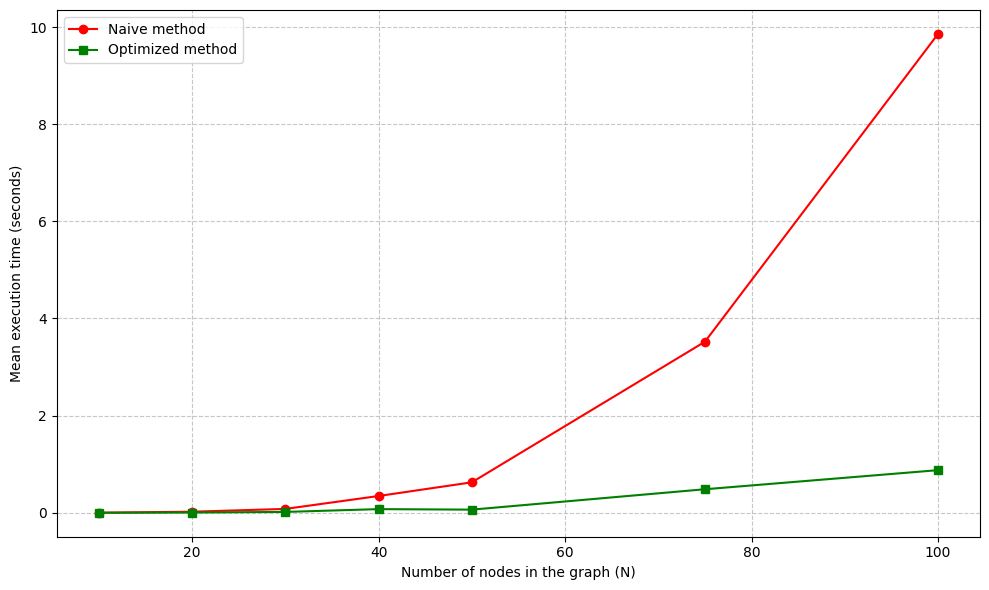

In [14]:

# parameters
node_sizes = [10, 20, 30, 40, 50, 75, 100]
num_trials = 3

times_naive_2 = []
times_optimized_2 = []

print("Benchmark starting...")
    
for n in node_sizes:
    t_naive_total = 0
    t_opt_total = 0
        
    for _ in range(num_trials):
        G, s, t = generate_random_flow_network(n, p=0.2)
            
        # naive method
        start = time.perf_counter()
        find_most_vital_edge_naive(G, s, t)
        t_naive_total += (time.perf_counter() - start)
            
        # optimized method
        start = time.perf_counter()
        find_most_vital_edge_optimized(G, s, t)
        t_opt_total += (time.perf_counter() - start)
            
    times_naive_2.append(t_naive_total / num_trials)
    times_optimized_2.append(t_opt_total / num_trials)
    print(f"Size N={n:3d} done. Naive: {times_naive_2[-1]:.4f}s | Optimized: {times_optimized_2[-1]:.4f}s")

# plotting
plt.figure(figsize=(10, 6))
plt.plot(node_sizes, times_naive_2, label='Naive method', marker='o', color='red')
plt.plot(node_sizes, times_optimized_2, label='Optimized method', marker='s', color='green')
    
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Mean execution time (seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
    
plt.tight_layout()
plt.show()

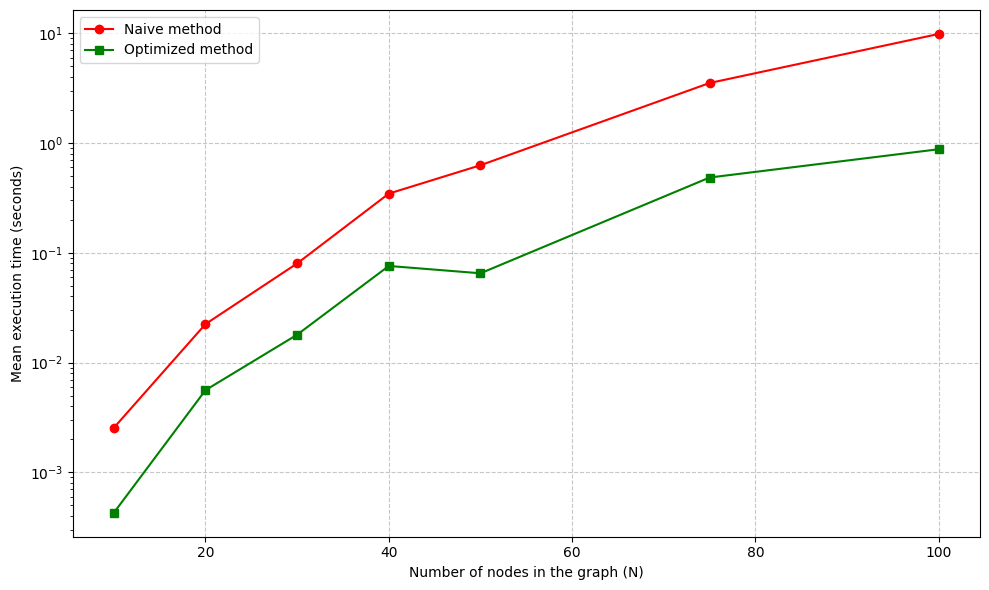

In [15]:
# plotting
plt.figure(figsize=(10, 6))
plt.plot(node_sizes, times_naive_2, label='Naive method', marker='o', color='red')
plt.plot(node_sizes, times_optimized_2, label='Optimized method', marker='s', color='green')
    
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Mean execution time (seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#log scale
plt.yscale('log') 

plt.tight_layout()
plt.show()

## Part 3: Optimal Sequence of k Edges Under Budget Constraint

**Mathematical Context:**
We transition to a Network Design Problem. You have a budget $B$. Introducing a decision variable $y_{ij} \geq 0$ representing the added capacity, the linear program becomes:
Maximize $v$ 
Subject to:
$$ \sum_{i} f_{ik} - \sum_{j} f_{kj} = 0 $$
$$ 0 \leq f_{ij} \leq c_{ij} + y_{ij} $$
$$ \sum_{(i,j) \in E} w_{ij} y_{ij} \leq B $$

**Greedy vs. Global Optimum (Submodularity):**
Why is the greedy algorithm not always optimal? Because the maximum flow function is **not strictly submodular** with respect to capacity addition. 
In a network, increasing the capacity of route A might yield **zero** gain until you *also* increase the capacity of the subsequent route B (synergy effect). The LP Solver evaluates the solution space holistically, capturing this synergy that the greedy algorithm misses.

In [16]:
def greedy_k_edges(G, s, t, k, delta=1.0):
    """Greedy approach: Iteratively selects the best single edge to upgrade."""
    G_temp = G.copy()
    chosen_edges = []
    
    for i in range(k):
        best_edge, max_gain = None, 0
        base_flow = nx.maximum_flow_value(G_temp, s, t)
        
        for u, v in G_temp.edges():
            G_temp[u][v]['capacity'] += delta
            gain = nx.maximum_flow_value(G_temp, s, t) - base_flow
            
            if gain > max_gain:
                max_gain = gain
                best_edge = (u, v)
                
            G_temp[u][v]['capacity'] -= delta
            
        if best_edge:
            chosen_edges.append(best_edge)
            G_temp[best_edge[0]][best_edge[1]]['capacity'] += delta
        else:
            break
            
    return chosen_edges, nx.maximum_flow_value(G_temp, s, t)



In [17]:
def exact_k_edges_ilp(G, s, t, k, delta=1.0):
    """Exact approach using Mixed Integer Linear Programming (MILP)."""
    prob = pulp.LpProblem("Max_Flow_Budget", pulp.LpMaximize)
    flows, upgrades = {}, {}
    
    for u, v in G.edges():
        flows[(u, v)] = pulp.LpVariable(f"flow_{u}_{v}", lowBound=0)
        upgrades[(u, v)] = pulp.LpVariable(f"up_{u}_{v}", cat=pulp.LpBinary)
        
    prob += pulp.lpSum([flows[(s, v)] for v in G.successors(s)]), "Total_Flow"
    prob += pulp.lpSum(upgrades.values()) <= k, "Budget"
    
    for u, v, data in G.edges(data=True):
        base_cap = data['capacity']
        prob += flows[(u, v)] <= base_cap + (upgrades[(u, v)] * delta)
        
    for node in G.nodes():
        if node not in [s, t]:
            prob += pulp.lpSum([flows[(u, node)] for u in G.predecessors(node)]) == \
                    pulp.lpSum([flows[(node, v)] for v in G.successors(node)])
            
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    chosen_edges = [(u, v) for u, v in G.edges() if pulp.value(upgrades[(u, v)]) > 0.5]
    return chosen_edges, pulp.value(prob.objective)

In [18]:
budget_k = 2
capacity_increase_delta = 15.0

print(f"--- Upgrading up to {budget_k} edges by +{capacity_increase_delta} units ---")

greedy_edges, greedy_flow = greedy_k_edges(wroclaw_graph, SOURCE, SINK, budget_k, capacity_increase_delta)
print("\n1. Greedy Algorithm Results:")
print(f"Chosen Edges: {greedy_edges}")
print(f"New Max Flow: {greedy_flow}")

exact_edges, exact_flow = exact_k_edges_ilp(wroclaw_graph, SOURCE, SINK, budget_k, capacity_increase_delta)
print("\n2. Exact Algorithm (ILP) Results:")
print(f"Chosen Edges: {exact_edges}")
print(f"New Max Flow: {exact_flow}")

if exact_flow > greedy_flow:
    print("\nObservation: The LP solver found a better synergy between edges than the greedy approach!")
elif exact_flow == greedy_flow:
    print("\nObservation: For this budget, the greedy approach matched the global optimum.")

--- Upgrading up to 2 edges by +15.0 units ---

1. Greedy Algorithm Results:
Chosen Edges: [('RescueBase', 'Politechnika Wroc.'), ('Politechnika Wroc.', 'Plac_Grunwaldzki')]
New Max Flow: 55.0

2. Exact Algorithm (ILP) Results:
Chosen Edges: [('RescueBase', 'Politechnika Wroc.'), ('Politechnika Wroc.', 'Plac_Grunwaldzki')]
New Max Flow: 55.0

Observation: For this budget, the greedy approach matched the global optimum.


### Benchmark

Benchmark starting for finding k edeges under constraints...
Size N= 10 done. Greedy: 0.0055s | Exact: 0.0210s
Size N= 15 done. Greedy: 0.0215s | Exact: 0.0271s
Size N= 20 done. Greedy: 0.0504s | Exact: 0.0282s
Size N= 25 done. Greedy: 0.0951s | Exact: 0.0300s
Size N= 30 done. Greedy: 0.2302s | Exact: 0.0340s


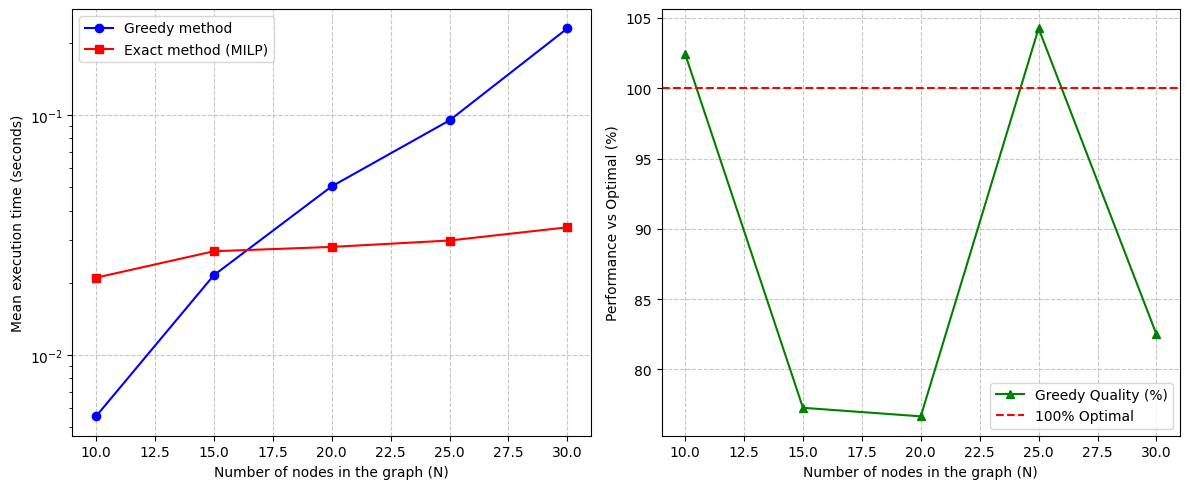

In [19]:


# parameters
node_sizes = [10, 15, 20, 25, 30]
num_trials = 3
k_edges = 2
delta_cap = 5.0

times_greedy = []
times_exact = []
flows_greedy = []
flows_exact = []

print("Benchmark starting for finding k edeges under constraints...")

for n in node_sizes:
    t_greedy_total = 0
    t_exact_total = 0
    flow_greedy_total = 0
    flow_exact_total = 0
    
    for _ in range(num_trials):
        G, s, t = generate_random_flow_network(n, 0.2)
        
        # greedy method
        start = time.perf_counter()
        _, flow_g = greedy_k_edges(G, s, t, k_edges, delta_cap)
        t_greedy_total += (time.perf_counter() - start)
        flow_greedy_total += flow_g
        
        # exact method (ILP)
        start = time.perf_counter()
        _, flow_e = exact_k_edges_ilp(G, s, t, k_edges, delta_cap)
        t_exact_total += (time.perf_counter() - start)
        flow_exact_total += flow_e
        
    times_greedy.append(t_greedy_total / num_trials)
    times_exact.append(t_exact_total / num_trials)
    flows_greedy.append(flow_greedy_total / num_trials)
    flows_exact.append(flow_exact_total / num_trials)
    
    print(f"Size N={n:3d} done. Greedy: {times_greedy[-1]:.4f}s | Exact: {times_exact[-1]:.4f}s")

# plotting
plt.figure(figsize=(12, 5))

# time comparison plot
plt.subplot(1, 2, 1)
plt.plot(node_sizes, times_greedy, label='Greedy method', marker='o', color='blue')
plt.plot(node_sizes, times_exact, label='Exact method (MILP)', marker='s', color='red')
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Mean execution time (seconds)")
plt.yscale('log') # Log scale is important here as MILP time grows exponentially
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# performance/quality comparison plot
plt.subplot(1, 2, 2)
ratios = [(g / e) * 100 if e > 0 else 100 for g, e in zip(flows_greedy, flows_exact)]
plt.plot(node_sizes, ratios, label='Greedy Quality (%)', marker='^', color='green')
plt.axhline(100, color='red', linestyle='--', label='100% Optimal')
plt.xlabel("Number of nodes in the graph (N)")
plt.ylabel("Performance vs Optimal (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()